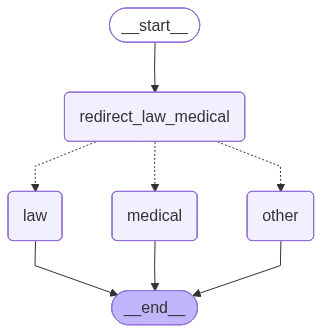

In [1]:
from typing import TypedDict , Literal
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel
from langgraph.graph import START , END , StateGraph
from dotenv import load_dotenv

load_dotenv()

# Question : law , medical , other

llm = ChatGroq(model = "openai/gpt-oss-120b")

# State
class State(TypedDict):
    question : str
    redirect : str
    answer : str


def redirect_law_medical(state: State) -> State:
    prompt = ChatPromptTemplate.from_messages(
        [("system" , 
          "You are a great question evaluator.\n"
          "You will receive one question\n"
          "You have to return 'Medical' if the questions is related to medical field\n"
          "If the questions is related to law then return 'Law'\n"
          "Other wise return 'Other'\n"
          "Please be very strict\n"),
          ("human" , "Your question is : {question}")]
    )
    class L_M_O(BaseModel):
        r : Literal["Medical" , "Law" , "Other"]
    
    chain = prompt | llm.with_structured_output(L_M_O)

    result = chain.invoke({"question" : state["question"]})

    return {"redirect" : result.r}

def routing_work(state: State) -> State:
    if state["redirect"] == "Medical":
        return "medical"
    elif state["redirect"] == "Law":
        return "law"
    else:
        return "other"

def medical(state: State) -> State:
    return {"answer" : "Hello Take Care"}

def law(state: State) -> State:
    return {"answer" : "Yes you are correct"}

def other(state: State) -> State:
    return {"answer" : "This is question is from outside."}


graph = StateGraph(State)

graph.add_node("redirect_law_medical" , redirect_law_medical)
graph.add_node("medical" , medical)
graph.add_node("law" , law)
graph.add_node("other" , other)


graph.add_edge(START , "redirect_law_medical")
graph.add_conditional_edges("redirect_law_medical",
                            routing_work,
                            {"medical" : "medical",
                             "law" : "law",
                             "other" : "other"})
graph.add_edge("law" , END)
graph.add_edge("medical" , END)
graph.add_edge("other" , END)

app = graph.compile()

app